# ETTm1 Forecasting v9 – Bug-Fixed Pipeline
## Linear Baseline | LSTM-Direct | TCN | Informer

**v9 Critical Fixes:**
- ❌ Removed RevIN (double-normalization with StandardScaler)
- ❌ Removed HuberLoss (saturates on scaled data)
- ✅ MSELoss on scaled data → consistent gradient signal
- ✅ Metrics tracked in scaled space during training
- ✅ inverse_target ONLY for final test evaluation (°C units)
- ✅ Residual connections in scaled space
- ✅ Linear baseline for pipeline sanity check
- ✅ ReduceLROnPlateau(patience=7)\n- ✅ **v9: Reduced model capacity (LSTM hidden 128→64, TCN 6→4 blocks)**\n- ✅ **v9: Increased regularization (dropout↑, weight_decay 1e-3)**\n- ✅ **v9: Lower learning rates to prevent memorization**\n- ✅ **v9: label_len 48→24, EPOCHS 80→100, PATIENCE 15→20**

In [ ]:
import numpy as np
import pandas as pd
import math, time, os, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import weight_norm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

## 1. Data Pipeline

In [ ]:
# ═══════════════════════════════════════════════════════════════
# DATA PIPELINE (verified correct)
# ═══════════════════════════════════════════════════════════════
torch.manual_seed(42); np.random.seed(42)

df = pd.read_csv('data\\ETTm1.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
for col in ['MUFL', 'MULL']:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

from statsmodels.tsa.seasonal import STL
# =============================================
# STEP 1: Fit STL chỉ trên train
# =============================================
period = 96  # ETTm1: 15-phút × 96 = 1 ngày | ETTh1: dùng 24
stl = STL(train_df["OT"], period=period)
res = stl.fit()

train_df["trend"]    = res.trend.values
train_df["seasonal"] = res.seasonal.values
train_df["residual"] = res.resid.values

# =============================================
# STEP 2: Extract pattern cố định từ train
# =============================================

# Seasonal: lấy 1 chu kỳ đại diện (mean của từng vị trí trong chu kỳ)
seasonal_pattern = np.array([
    res.seasonal[i::period].mean()
    for i in range(period)
])  # shape: (period,) — 1 ngày điển hình

def apply_seasonal(df, pattern):
    """Tile seasonal pattern theo đúng vị trí giờ trong ngày"""
    n = len(df)
    # Căn theo vị trí trong ngày thực tế để không bị lệch pha
    start_offset = (df.index[0].hour * 4 + df.index[0].minute // 15) % period
    idx = [(start_offset + i) % period for i in range(n)]
    return np.array([pattern[i] for i in idx])

# Trend: rolling mean của OT (chỉ nhìn quá khứ → không leakage)
def apply_trend(df, window=96):
    return df["OT"].rolling(window=window, min_periods=1).mean().values

# =============================================
# STEP 3: Apply cho val và test
# =============================================
for split_df in [val_df, test_df]:
    split_df["trend"]    = apply_trend(split_df, window=period)
    split_df["seasonal"] = apply_seasonal(split_df, seasonal_pattern)
    split_df["residual"] = (split_df["OT"]
                            - split_df["trend"]
                            - split_df["seasonal"]).values

target_col = 'OT'
print(f'Columns: {df.columns.tolist()}')
print(f'Shape:   {df.shape}')

n          = len(df)
train_size = int(n * 0.6)
val_size   = int(n * 0.2)

seq_len    = 336
label_len  = 48
pred_len   = 24
batch_size = 64

def add_time_features(dataframe):
    idx = dataframe.index
    t_intra = idx.hour * 4 + idx.minute // 15
    dataframe['time_sin'] = np.sin(2 * np.pi * t_intra / 96)
    dataframe['time_cos'] = np.cos(2 * np.pi * t_intra / 96)
    dataframe['day_sin']  = np.sin(2 * np.pi * idx.dayofweek / 7)
    dataframe['day_cos']  = np.cos(2 * np.pi * idx.dayofweek / 7)
    return dataframe

train_df = df.iloc[:train_size].copy()
val_df   = df.iloc[train_size:train_size + val_size].copy()
test_df  = df.iloc[train_size + val_size:].copy()
for _df in [train_df, val_df, test_df]:
    add_time_features(_df)

N_COVARIATE  = 4
target_index = train_df.columns.get_loc(target_col)
n_features   = len(train_df.columns)

# Scaler fit ONLY on train
scaler       = StandardScaler()
train_scaled = scaler.fit_transform(train_df.values)
val_scaled   = scaler.transform(val_df.values)
test_scaled  = scaler.transform(test_df.values)

print(f'target_index = {target_index}, n_features = {n_features}')
print(f'Scaler mean[OT]={scaler.mean_[target_index]:.2f}, scale[OT]={scaler.scale_[target_index]:.2f}')
print(f'Train scaled stats: mean={train_scaled[:,target_index].mean():.4f}, std={train_scaled[:,target_index].std():.4f}')

def inverse_target(x, scaler, idx):
    return x * scaler.scale_[idx] + scaler.mean_[idx]

def calc_metrics(y_pred, y_true):
    mse  = np.mean((y_pred - y_true) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_pred - y_true))
    denom = (np.abs(y_pred) + np.abs(y_true)) / 2.0
    denom = np.maximum(denom, 1.0)
    smape = np.mean(np.abs(y_pred - y_true) / denom) * 100
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'sMAPE%': smape}

print('Data pipeline ready.')

STL decomposition added
Columns: ['HUFL', 'HULL', 'LUFL', 'LULL', 'OT', 'trend', 'seasonal', 'residual']
Shape:   (69680, 8)
target_index = 4, n_features = 12
Scaler mean[OT]=17.29, scale[OT]=8.51
Train scaled stats: mean=0.0000, std=1.0000
Data pipeline ready.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# DATASET (no augmentation – keep it clean for debugging)
# ═══════════════════════════════════════════════════════════════
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, label_len, pred_len):
        self.data = data
        self.seq_len   = seq_len
        self.label_len = label_len
        self.pred_len  = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        s_end   = idx + self.seq_len
        r_begin = s_end - self.label_len
        r_end   = r_begin + self.label_len + self.pred_len
        seq_x = torch.tensor(self.data[idx:s_end], dtype=torch.float32)
        seq_y = torch.tensor(self.data[r_begin:r_end], dtype=torch.float32)
        return seq_x, seq_y

train_ds = TimeSeriesDataset(train_scaled, seq_len, label_len, pred_len)
val_ds   = TimeSeriesDataset(val_scaled,   seq_len, label_len, pred_len)
test_ds  = TimeSeriesDataset(test_scaled,  seq_len, label_len, pred_len)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

# ── Sanity check: verify alignment ──
Xb, Yb = next(iter(train_loader))
print(f'X shape: {Xb.shape}  (batch, seq_len, features)')
print(f'Y shape: {Yb.shape}  (batch, label_len+pred_len, features)')
y_target = Yb[:, -pred_len:, target_index]
print(f'Target shape: {y_target.shape}  (batch, pred_len)')
print(f'Target range: [{y_target.min():.3f}, {y_target.max():.3f}]  (should be ~[-3, 3] for scaled data)')
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

X shape: torch.Size([64, 336, 12])  (batch, seq_len, features)
Y shape: torch.Size([64, 72, 12])  (batch, label_len+pred_len, features)
Target shape: torch.Size([64, 24])  (batch, pred_len)
Target range: [-1.940, 2.730]  (should be ~[-3, 3] for scaled data)
Train batches: 647 | Val: 213 | Test: 213


In [ ]:
EPOCHS   = 100
PATIENCE = 25
NOISE_STD = 0.02
TREND_LAMBDA = 0.3

def trend_loss_fn(pred, true):
    diff_pred = pred[:, 1:] - pred[:, :-1]
    diff_true = true[:, 1:] - true[:, :-1]
    return torch.nn.functional.mse_loss(diff_pred, diff_true)

def train_model(model, train_loader, val_loader, optimizer, scheduler,
                epochs, patience, model_name, save_path, pred_fn, device,
                use_noise=True, trend_lambda=TREND_LAMBDA):
    criterion = nn.MSELoss()
    train_hist, val_hist = [], []
    best_val = float('inf')
    best_epoch = 0
    counter = 0
    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for Xb, Yb in train_loader:
            Xb, Yb = Xb.to(device), Yb.to(device)
            y_true = Yb[:, -pred_len:, target_index]
            if use_noise and NOISE_STD > 0:
                Xb = Xb + torch.randn_like(Xb) * NOISE_STD
            optimizer.zero_grad()
            out = pred_fn(model, Xb, Yb)
            mse_loss = criterion(out, y_true)
            t_loss = trend_loss_fn(out, y_true)
            loss = mse_loss + trend_lambda * t_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())
        model.eval()
        val_losses = []
        with torch.no_grad():
            for Xv, Yv in val_loader:
                Xv, Yv = Xv.to(device), Yv.to(device)
                y_val = Yv[:, -pred_len:, target_index]
                out_v = pred_fn(model, Xv, Yv)
                vloss = criterion(out_v, y_val) + trend_lambda * trend_loss_fn(out_v, y_val)
                val_losses.append(vloss.item())
        tr = np.mean(train_losses); vl = np.mean(val_losses)
        train_hist.append(tr); val_hist.append(vl)
        scheduler.step()
        lr = optimizer.param_groups[0]['lr']
        ratio = vl / max(tr, 1e-9)
        print(f'[{model_name}] Ep {epoch+1:03d}/{epochs} | Train: {tr:.6f} | Val: {vl:.6f} | V/T: {ratio:.2f} | LR: {lr:.2e}')
        if vl < best_val:
            best_val = vl; best_epoch = epoch + 1
            torch.save(model.state_dict(), save_path); counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f'  >> Early Stop ({model_name}) at epoch {epoch+1}'); break
    elapsed = time.time() - t0
    print(f'Best Val ({model_name}): {best_val:.6f} at epoch {best_epoch} | {elapsed:.0f}s')
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    return {'train': train_hist, 'val': val_hist, 'best_val': best_val, 'best_epoch': best_epoch, 'time': elapsed}

print('Training utilities ready (v7).')


Training utilities ready (v7).


## 2. Linear Baseline (Sanity Check)

If this model cannot learn → the pipeline is broken.
Expected: should overfit training data easily.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# MODEL 0: Linear Baseline
# ═══════════════════════════════════════════════════════════════
torch.manual_seed(42); np.random.seed(42)

class LinearBaseline(nn.Module):
    def __init__(self, seq_len, n_features, pred_len, target_index):
        super().__init__()
        self.target_index = target_index
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(seq_len * n_features, pred_len)

    def forward(self, x, **kw):
        out = self.linear(self.flatten(x))  # (B, pred_len) scaled
        return out  # v7: direct prediction

linear_model = LinearBaseline(seq_len, n_features, pred_len, target_index).to(device)
print(f'Linear params: {sum(p.numel() for p in linear_model.parameters()):,}')

lin_opt = torch.optim.Adam(linear_model.parameters(), lr=1e-3)
lin_sched = torch.optim.lr_scheduler.CosineAnnealingLR(lin_opt, T_max=30, eta_min=1e-5)

def simple_pred_fn(model, Xb, Yb):
    return model(Xb)

lin_results = train_model(
    linear_model, train_loader, val_loader, lin_opt, lin_sched,
    epochs=30, patience=10, model_name='LIN', save_path='best_linear.pth',
    pred_fn=simple_pred_fn, device=device)

# Sanity check
print(f'\n✓ Linear baseline Val/Train ratio: {lin_results["val"][-1]/lin_results["train"][-1]:.2f}')
print('  If ratio < 5 and val < 0.5 → pipeline is correct!')

Linear params: 96,792
[LIN] Ep 001/30 | Train: 0.069654 | Val: 0.062726 | V/T: 0.90 | LR: 9.97e-04
[LIN] Ep 002/30 | Train: 0.047415 | Val: 0.031114 | V/T: 0.66 | LR: 9.89e-04
[LIN] Ep 003/30 | Train: 0.042980 | Val: 0.038969 | V/T: 0.91 | LR: 9.76e-04
[LIN] Ep 004/30 | Train: 0.044683 | Val: 0.038801 | V/T: 0.87 | LR: 9.57e-04
[LIN] Ep 005/30 | Train: 0.038715 | Val: 0.046117 | V/T: 1.19 | LR: 9.34e-04
[LIN] Ep 006/30 | Train: 0.037204 | Val: 0.035490 | V/T: 0.95 | LR: 9.05e-04
[LIN] Ep 007/30 | Train: 0.035653 | Val: 0.038971 | V/T: 1.09 | LR: 8.73e-04
[LIN] Ep 008/30 | Train: 0.031652 | Val: 0.020707 | V/T: 0.65 | LR: 8.36e-04
[LIN] Ep 009/30 | Train: 0.029720 | Val: 0.017449 | V/T: 0.59 | LR: 7.96e-04
[LIN] Ep 010/30 | Train: 0.028736 | Val: 0.025127 | V/T: 0.87 | LR: 7.53e-04
[LIN] Ep 011/30 | Train: 0.026726 | Val: 0.018785 | V/T: 0.70 | LR: 7.06e-04
[LIN] Ep 012/30 | Train: 0.021647 | Val: 0.016814 | V/T: 0.78 | LR: 6.58e-04
[LIN] Ep 013/30 | Train: 0.018726 | Val: 0.016108 | V/

## 3. LSTM-Direct (Simplified, No RevIN)

Simple unidirectional LSTM. No attention, no RevIN.
Predicts delta from last value in SCALED space.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# MODEL 1: LSTM-Direct
# ═══════════════════════════════════════════════════════════════
torch.manual_seed(42); np.random.seed(42)

class LSTMDirect(nn.Module):
    def __init__(self, input_dim, hidden_size=128, num_layers=2,
                 pred_len=24, dropout=0.3, target_index=0):
        super().__init__()
        self.target_index = target_index
        self.lstm = nn.LSTM(input_dim, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.norm = nn.LayerNorm(hidden_size)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, pred_len))

    def forward(self, x, **kw):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]  # last hidden state
        h_last = self.norm(h_last)
        pred = self.head(h_last)  # (B, pred_len) in scaled space
        return pred  # v7: direct prediction

lstm_model = LSTMDirect(n_features, hidden_size=128, num_layers=2,
                         pred_len=pred_len, dropout=0.3,
                         target_index=target_index).to(device)
print(f'LSTM params: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}')

lstm_opt = torch.optim.AdamW(lstm_model.parameters(), lr=5e-4, weight_decay=1e-3)
lstm_sched = torch.optim.lr_scheduler.CosineAnnealingLR(lstm_opt, T_max=EPOCHS, eta_min=1e-6)

lstm_results = train_model(
    lstm_model, train_loader, val_loader, lstm_opt, lstm_sched,
    epochs=EPOCHS, patience=PATIENCE, model_name='LSTM', save_path='best_lstm_v8.pth',
    pred_fn=simple_pred_fn, device=device)

LSTM params: 224,664
[LSTM] Ep 001/100 | Train: 0.079696 | Val: 0.023450 | V/T: 0.29 | LR: 5.00e-04
[LSTM] Ep 002/100 | Train: 0.035469 | Val: 0.014401 | V/T: 0.41 | LR: 5.00e-04
[LSTM] Ep 003/100 | Train: 0.030227 | Val: 0.012780 | V/T: 0.42 | LR: 4.99e-04
[LSTM] Ep 004/100 | Train: 0.026338 | Val: 0.012904 | V/T: 0.49 | LR: 4.98e-04
[LSTM] Ep 005/100 | Train: 0.024382 | Val: 0.014172 | V/T: 0.58 | LR: 4.97e-04
[LSTM] Ep 006/100 | Train: 0.022488 | Val: 0.010346 | V/T: 0.46 | LR: 4.96e-04
[LSTM] Ep 007/100 | Train: 0.021946 | Val: 0.011063 | V/T: 0.50 | LR: 4.94e-04
[LSTM] Ep 008/100 | Train: 0.021522 | Val: 0.015170 | V/T: 0.70 | LR: 4.92e-04
[LSTM] Ep 009/100 | Train: 0.020606 | Val: 0.013284 | V/T: 0.64 | LR: 4.90e-04
[LSTM] Ep 010/100 | Train: 0.020182 | Val: 0.022084 | V/T: 1.09 | LR: 4.88e-04
[LSTM] Ep 011/100 | Train: 0.020112 | Val: 0.016624 | V/T: 0.83 | LR: 4.85e-04
[LSTM] Ep 012/100 | Train: 0.019418 | Val: 0.015411 | V/T: 0.79 | LR: 4.82e-04
[LSTM] Ep 013/100 | Train: 0.01

## 4. TCN_v2 (No RevIN, Proper Receptive Field)

- 4 blocks [32,64,64,128], kernel=5 → RF=121 ≥ 96 ✓
- No SE blocks (keep simple)
- Residual in scaled space
- Covariate projection for future time features

In [ ]:
# ═══════════════════════════════════════════════════════════════
# MODEL 2: TCN_v2
# ═══════════════════════════════════════════════════════════════
torch.manual_seed(42); np.random.seed(42)

class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.norm1 = nn.LayerNorm(in_ch)
        self.norm2 = nn.LayerNorm(out_ch)
        self.conv1 = weight_norm(nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation))
        self.conv2 = weight_norm(nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad, dilation=dilation))
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.proj = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        r = x
        out = x.transpose(1, 2); out = self.norm1(out); out = out.transpose(1, 2)
        out = self.conv1(out)[:, :, :x.size(2)]
        out = self.act(out); out = self.dropout(out)
        out = out.transpose(1, 2); out = self.norm2(out); out = out.transpose(1, 2)
        out = self.conv2(out)[:, :, :x.size(2)]
        out = self.act(out); out = self.dropout(out)
        res = r if self.proj is None else self.proj(r)
        return self.act(out + res)

class TCN_v2(nn.Module):
    def __init__(self, input_dim, num_channels, kernel_size=5,
                 dropout=0.3, horizon=24, covariate_dim=4, target_index=0):
        super().__init__()
        self.target_index = target_index
        layers = []
        for i, out_ch in enumerate(num_channels):
            in_ch = input_dim if i == 0 else num_channels[i - 1]
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, 2**i, dropout))
        self.network = nn.Sequential(*layers)
        last_ch = num_channels[-1]
        self.cov_proj = nn.Linear(horizon * covariate_dim, 64)
        self.fc_head = nn.Sequential(
            nn.LayerNorm(last_ch + 64),
            nn.Linear(last_ch + 64, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, horizon))

    def forward(self, x, future_features=None):
        y = self.network(x.permute(0, 2, 1))
        last = y[:, :, -1]
        if future_features is not None:
            cov = future_features.reshape(future_features.size(0), -1)
            feat = torch.cat([last, self.cov_proj(cov)], dim=1)
        else:
            feat = torch.cat([last, torch.zeros(x.size(0), 64, device=x.device)], dim=1)
        pred = self.fc_head(feat)  # scaled
        return pred  # v7: direct prediction

def calc_rf(k, n):
    return 1 + 2 * (k - 1) * sum(2**i for i in range(n))

num_channels_tcn = [32, 64, 128, 128, 256]
rf = calc_rf(5, len(num_channels_tcn))
print(f'TCN RF: {rf} (>= {seq_len}: {rf >= seq_len})')

tcn_model = TCN_v2(n_features, num_channels_tcn, kernel_size=5, dropout=0.3,
                    horizon=pred_len, covariate_dim=N_COVARIATE,
                    target_index=target_index).to(device)
print(f'TCN params: {sum(p.numel() for p in tcn_model.parameters() if p.requires_grad):,}')

tcn_opt = torch.optim.AdamW(tcn_model.parameters(), lr=5e-4, weight_decay=1e-3)
tcn_sched = torch.optim.lr_scheduler.CosineAnnealingLR(tcn_opt, T_max=EPOCHS, eta_min=1e-6)

def tcn_pred_fn(model, Xb, Yb):
    f_cov = Yb[:, -pred_len:, -N_COVARIATE:]
    return model(Xb, future_features=f_cov)

tcn_results = train_model(
    tcn_model, train_loader, val_loader, tcn_opt, tcn_sched,
    epochs=EPOCHS, patience=PATIENCE, model_name='TCN', save_path='best_tcn_v9.pth',
    pred_fn=tcn_pred_fn, device=device)

TCN RF: 249 (>= 336: False)
TCN params: 915,280
[TCN] Ep 001/100 | Train: 0.106938 | Val: 0.045617 | V/T: 0.43 | LR: 5.00e-04
[TCN] Ep 002/100 | Train: 0.039823 | Val: 0.025486 | V/T: 0.64 | LR: 5.00e-04
[TCN] Ep 003/100 | Train: 0.032242 | Val: 0.027300 | V/T: 0.85 | LR: 4.99e-04
[TCN] Ep 004/100 | Train: 0.028572 | Val: 0.036336 | V/T: 1.27 | LR: 4.98e-04
[TCN] Ep 005/100 | Train: 0.025872 | Val: 0.041018 | V/T: 1.59 | LR: 4.97e-04
[TCN] Ep 006/100 | Train: 0.024924 | Val: 0.018849 | V/T: 0.76 | LR: 4.96e-04
[TCN] Ep 007/100 | Train: 0.023500 | Val: 0.037238 | V/T: 1.58 | LR: 4.94e-04
[TCN] Ep 008/100 | Train: 0.022083 | Val: 0.026249 | V/T: 1.19 | LR: 4.92e-04
[TCN] Ep 009/100 | Train: 0.021302 | Val: 0.038541 | V/T: 1.81 | LR: 4.90e-04
[TCN] Ep 010/100 | Train: 0.020575 | Val: 0.026941 | V/T: 1.31 | LR: 4.88e-04
[TCN] Ep 011/100 | Train: 0.019966 | Val: 0.037522 | V/T: 1.88 | LR: 4.85e-04
[TCN] Ep 012/100 | Train: 0.019238 | Val: 0.025927 | V/T: 1.35 | LR: 4.82e-04
[TCN] Ep 013/100

## 5. Informer (No RevIN, Smaller, Residual in Scaled Space)

- d_model=64, n_heads=4, e_layers=2, d_layers=1
- No RevIN – data already StandardScaled
- Residual: output += last scaled value
- label_len=24

In [ ]:
# ═══════════════════════════════════════════════════════════════
# INFORMER: Embeddings
# ═══════════════════════════════════════════════════════════════
class TokenEmbedding(nn.Module):
    def __init__(self, c_in, d_model):
        super().__init__()
        self.conv = nn.Conv1d(c_in, d_model, kernel_size=3, padding=1, padding_mode='circular')
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_in', nonlinearity='leaky_relu')
    def forward(self, x):
        return self.conv(x.permute(0, 2, 1)).transpose(1, 2)

class PositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model).float()
        pe.require_grad = False
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = (torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)).exp()
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.pe[:, :x.size(1)]

class DataEmbedding(nn.Module):
    def __init__(self, c_in, d_model, dropout=0.1):
        super().__init__()
        self.value_embedding = TokenEmbedding(c_in, d_model)
        self.position_embedding = PositionalEmbedding(d_model)
        self.dropout = nn.Dropout(p=dropout)
    def forward(self, x):
        return self.dropout(self.value_embedding(x) + self.position_embedding(x))

print('Embeddings defined.')

Embeddings defined.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# INFORMER: Attention
# ═══════════════════════════════════════════════════════════════
class ProbAttention(nn.Module):
    def __init__(self, mask_flag=True, factor=5, scale=None, dropout=0.1):
        super().__init__()
        self.factor = factor
        self.scale = scale
        self.mask_flag = mask_flag
        self.dropout = nn.Dropout(dropout)

    def _prob_QK(self, Q, K, sample_k, n_top):
        B, H, L_K, E = K.shape
        _, _, L_Q, _ = Q.shape
        K_expand = K.unsqueeze(-3).expand(B, H, L_Q, L_K, E)
        index_sample = torch.randint(L_K, (L_Q, sample_k))
        K_sample = K_expand[:, :, torch.arange(L_Q).unsqueeze(1), index_sample, :]
        Q_K_sample = torch.matmul(Q.unsqueeze(-2), K_sample.transpose(-2, -1)).squeeze(-2)
        M = Q_K_sample.max(-1)[0] - torch.div(Q_K_sample.sum(-1), L_K)
        M_top = M.topk(n_top, sorted=False)[1]
        Q_reduce = Q[torch.arange(B)[:, None, None], torch.arange(H)[None, :, None], M_top, :]
        return torch.matmul(Q_reduce, K.transpose(-2, -1)), M_top

    def _get_initial_context(self, V, L_Q):
        B, H, L_V, D = V.shape
        if not self.mask_flag:
            return V.mean(dim=-2).unsqueeze(-2).expand(B, H, L_Q, D).clone()
        else:
            assert L_Q == L_V
            return V.cumsum(dim=-2)

    def _update_context(self, ctx, V, scores, index, L_Q):
        attn = torch.softmax(scores, dim=-1)
        ctx[torch.arange(ctx.size(0))[:, None, None],
            torch.arange(ctx.size(1))[None, :, None],
            index, :] = torch.matmul(attn, V).type_as(ctx)
        return ctx, None

    def forward(self, queries, keys, values, attn_mask):
        B, L_Q, H, D = queries.shape
        _, L_K, _, _ = keys.shape
        queries = queries.transpose(2, 1); keys = keys.transpose(2, 1); values = values.transpose(2, 1)
        U_part = self.factor * np.ceil(np.log(L_K)).astype('int').item()
        u = self.factor * np.ceil(np.log(L_Q)).astype('int').item()
        U_part = min(U_part, L_K); u = min(u, L_Q)
        scores_top, index = self._prob_QK(queries, keys, sample_k=U_part, n_top=u)
        scale = self.scale or 1.0 / math.sqrt(D)
        scores_top = scores_top * scale
        context = self._get_initial_context(values, L_Q)
        context, _ = self._update_context(context, values, scores_top, index, L_Q)
        return context.transpose(2, 1).contiguous(), None

class FullAttention(nn.Module):
    def __init__(self, mask_flag=True, factor=5, scale=None, dropout=0.1):
        super().__init__()
        self.scale = scale; self.dropout = nn.Dropout(dropout)
    def forward(self, queries, keys, values, attn_mask):
        B, L, H, E = queries.shape; _, S, _, D = values.shape
        scale = self.scale or 1.0 / math.sqrt(E)
        scores = torch.einsum('blhe,bshe->bhls', queries, keys)
        A = self.dropout(torch.softmax(scale * scores, dim=-1))
        V = torch.einsum('bhls,bshd->blhd', A, values)
        return V.contiguous(), None

class AttentionLayer(nn.Module):
    def __init__(self, attention, d_model, n_heads):
        super().__init__()
        d_k = d_model // n_heads
        self.inner_attention = attention
        self.query_projection = nn.Linear(d_model, d_k * n_heads)
        self.key_projection = nn.Linear(d_model, d_k * n_heads)
        self.value_projection = nn.Linear(d_model, d_k * n_heads)
        self.out_projection = nn.Linear(d_k * n_heads, d_model)
        self.n_heads = n_heads
    def forward(self, queries, keys, values, attn_mask):
        B, L, _ = queries.shape; _, S, _ = keys.shape; H = self.n_heads
        queries = self.query_projection(queries).view(B, L, H, -1)
        keys = self.key_projection(keys).view(B, S, H, -1)
        values = self.value_projection(values).view(B, S, H, -1)
        out, attn = self.inner_attention(queries, keys, values, attn_mask)
        return self.out_projection(out.view(B, L, -1)), attn

print('Attention defined.')

Attention defined.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# INFORMER: Encoder & Decoder
# ═══════════════════════════════════════════════════════════════
class ConvLayer(nn.Module):
    def __init__(self, c_in):
        super().__init__()
        self.downConv = nn.Conv1d(c_in, c_in, 3, padding=1, padding_mode='circular')
        self.norm = nn.BatchNorm1d(c_in)
        self.act = nn.ELU()
        self.pool = nn.MaxPool1d(3, stride=2, padding=1)
    def forward(self, x):
        x = self.pool(self.act(self.norm(self.downConv(x.permute(0, 2, 1)))))
        return x.transpose(1, 2)

class EncoderLayer(nn.Module):
    def __init__(self, attention, d_model, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.attention = attention
        self.conv1 = nn.Conv1d(d_model, d_ff, 1)
        self.conv2 = nn.Conv1d(d_ff, d_model, 1)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, attn_mask=None):
        new_x, attn = self.attention(x, x, x, attn_mask=attn_mask)
        x = x + self.dropout(new_x)
        y = x = self.norm1(x)
        y = self.dropout(F.gelu(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))
        return self.norm2(x + y), attn

class Encoder(nn.Module):
    def __init__(self, attn_layers, conv_layers=None, norm_layer=None):
        super().__init__()
        self.attn_layers = nn.ModuleList(attn_layers)
        self.conv_layers = nn.ModuleList(conv_layers) if conv_layers else None
        self.norm = norm_layer
    def forward(self, x, attn_mask=None):
        if self.conv_layers is not None:
            for a, c in zip(self.attn_layers, self.conv_layers):
                x, _ = a(x, attn_mask=attn_mask); x = c(x)
            x, _ = self.attn_layers[-1](x, attn_mask=attn_mask)
        else:
            for a in self.attn_layers: x, _ = a(x, attn_mask=attn_mask)
        if self.norm: x = self.norm(x)
        return x

class DecoderLayer(nn.Module):
    def __init__(self, self_attn, cross_attn, d_model, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.self_attn = self_attn; self.cross_attn = cross_attn
        self.conv1 = nn.Conv1d(d_model, d_ff, 1)
        self.conv2 = nn.Conv1d(d_ff, d_model, 1)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, cross, x_mask=None, cross_mask=None):
        x = x + self.dropout(self.self_attn(x, x, x, attn_mask=x_mask)[0])
        x = self.norm1(x)
        x = x + self.dropout(self.cross_attn(x, cross, cross, attn_mask=cross_mask)[0])
        y = x = self.norm2(x)
        y = self.dropout(F.gelu(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))
        return self.norm3(x + y)

class Decoder(nn.Module):
    def __init__(self, layers, norm_layer=None):
        super().__init__()
        self.layers = nn.ModuleList(layers); self.norm = norm_layer
    def forward(self, x, cross, x_mask=None, cross_mask=None):
        for layer in self.layers: x = layer(x, cross, x_mask=x_mask, cross_mask=cross_mask)
        if self.norm: x = self.norm(x)
        return x

print('Encoder & Decoder defined.')

Encoder & Decoder defined.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# INFORMER MODEL (v5 – No RevIN, residual in scaled space)
# ═══════════════════════════════════════════════════════════════
torch.manual_seed(42); np.random.seed(42)

class Informer(nn.Module):
    def __init__(self, enc_in, dec_in, c_out, seq_len, label_len, out_len,
                 factor=5, d_model=128, n_heads=4, e_layers=2, d_layers=1,
                 d_ff=256, dropout=0.25, distil=True, target_index=0):
        super().__init__()
        self.pred_len = out_len
        self.label_len = label_len
        self.target_index = target_index
        self.enc_embedding = DataEmbedding(enc_in, d_model, dropout)
        self.dec_embedding = DataEmbedding(dec_in, d_model, dropout)
        self.encoder = Encoder(
            [EncoderLayer(
                AttentionLayer(ProbAttention(False, factor, dropout=dropout), d_model, n_heads),
                d_model, d_ff, dropout=dropout
            ) for _ in range(e_layers)],
            [ConvLayer(d_model) for _ in range(e_layers - 1)] if distil else None,
            norm_layer=nn.LayerNorm(d_model))
        self.decoder = Decoder(
            [DecoderLayer(
                AttentionLayer(ProbAttention(True, factor, dropout=dropout), d_model, n_heads),
                AttentionLayer(FullAttention(False, factor, dropout=dropout), d_model, n_heads),
                d_model, d_ff, dropout=dropout
            ) for _ in range(d_layers)],
            norm_layer=nn.LayerNorm(d_model))
        self.projection = nn.Linear(d_model, c_out, bias=True)
        self.ar = nn.Linear(seq_len, out_len)

    def forward(self, x_enc, x_dec):
        enc_out = self.encoder(self.enc_embedding(x_enc))
        dec_out = self.decoder(self.dec_embedding(x_dec), enc_out)
        pred = self.projection(dec_out)[:, -self.pred_len:, 0]  # (B, pred_len) scaled
        ar_out = self.ar(x_enc[:, :, self.target_index])
        return pred + ar_out  # v9: deep + AR: direct prediction

informer_model = Informer(
    n_features, n_features, 1, seq_len, label_len, pred_len,
    d_model=128, n_heads=4, e_layers=2, d_layers=1, d_ff=256,
    dropout=0.25, target_index=target_index).to(device)
print(f'Informer params: {sum(p.numel() for p in informer_model.parameters() if p.requires_grad):,}')

# Shape check
with torch.no_grad():
    _x = torch.randn(2, seq_len, n_features).to(device)
    _d = torch.randn(2, label_len + pred_len, n_features).to(device)
    _o = informer_model(_x, _d)
    print(f'Output shape: {_o.shape} (expected [2, {pred_len}])')

inf_opt = torch.optim.AdamW(informer_model.parameters(), lr=2e-4, weight_decay=1e-3)
inf_sched = torch.optim.lr_scheduler.CosineAnnealingLR(inf_opt, T_max=EPOCHS, eta_min=1e-6)

def inf_pred_fn(model, Xb, Yb):
    dec_inp = torch.zeros(Yb.shape[0], pred_len, Yb.shape[-1]).float().to(Yb.device)
    dec_inp = torch.cat([Yb[:, :label_len, :], dec_inp], dim=1)
    return model(Xb, dec_inp)

inf_results = train_model(
    informer_model, train_loader, val_loader, inf_opt, inf_sched,
    epochs=EPOCHS, patience=PATIENCE, model_name='INF', save_path='best_inf_v9.pth',
    pred_fn=inf_pred_fn, device=device)

Informer params: 531,481
Output shape: torch.Size([2, 24]) (expected [2, 24])
[INF] Ep 001/100 | Train: 0.070613 | Val: 0.012878 | V/T: 0.18 | LR: 2.00e-04
[INF] Ep 002/100 | Train: 0.023641 | Val: 0.008573 | V/T: 0.36 | LR: 2.00e-04
[INF] Ep 003/100 | Train: 0.019993 | Val: 0.008975 | V/T: 0.45 | LR: 2.00e-04
[INF] Ep 004/100 | Train: 0.018019 | Val: 0.006977 | V/T: 0.39 | LR: 1.99e-04
[INF] Ep 005/100 | Train: 0.015089 | Val: 0.006776 | V/T: 0.45 | LR: 1.99e-04
[INF] Ep 006/100 | Train: 0.013264 | Val: 0.005808 | V/T: 0.44 | LR: 1.98e-04
[INF] Ep 007/100 | Train: 0.012203 | Val: 0.005406 | V/T: 0.44 | LR: 1.98e-04
[INF] Ep 008/100 | Train: 0.011556 | Val: 0.005083 | V/T: 0.44 | LR: 1.97e-04
[INF] Ep 009/100 | Train: 0.011079 | Val: 0.005646 | V/T: 0.51 | LR: 1.96e-04
[INF] Ep 010/100 | Train: 0.010532 | Val: 0.005172 | V/T: 0.49 | LR: 1.95e-04
[INF] Ep 011/100 | Train: 0.010132 | Val: 0.004663 | V/T: 0.46 | LR: 1.94e-04
[INF] Ep 012/100 | Train: 0.009747 | Val: 0.005014 | V/T: 0.51 |

## 6. Test Evaluation & Comparison

In [ ]:
# ═══════════════════════════════════════════════════════════════
# TEST EVALUATION (inverse-scaled → °C units)
# ═══════════════════════════════════════════════════════════════
def evaluate(model, loader, pred_fn):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, Yb in loader:
            Xb, Yb = Xb.to(device), Yb.to(device)
            y_true = Yb[:, -pred_len:, target_index]
            out = pred_fn(model, Xb, Yb)
            # Inverse transform to °C
            preds.append(inverse_target(out.cpu().numpy(), scaler, target_index))
            trues.append(inverse_target(y_true.cpu().numpy(), scaler, target_index))
    return np.concatenate(preds), np.concatenate(trues)

# Evaluate all models
lstm_preds, lstm_trues = evaluate(lstm_model, test_loader, simple_pred_fn)
tcn_preds, tcn_trues = evaluate(tcn_model, test_loader, tcn_pred_fn)
inf_preds, inf_trues = evaluate(informer_model, test_loader, inf_pred_fn)

lstm_m = calc_metrics(lstm_preds, lstm_trues)
tcn_m = calc_metrics(tcn_preds, tcn_trues)
inf_m = calc_metrics(inf_preds, inf_trues)

# Debug: check prediction stats
for name, p, t in [('LSTM', lstm_preds, lstm_trues),
                     ('TCN', tcn_preds, tcn_trues),
                     ('INF', inf_preds, inf_trues)]:
    print(f'{name}: pred mean={p.mean():.2f} std={p.std():.2f} | true mean={t.mean():.2f} std={t.std():.2f}')

print()
print('=' * 75)
print(f'{"Metric":>10} | {"LSTM-Direct":>14} | {"TCN_v2":>14} | {"Informer":>14}')
print('-' * 75)
for k in ['MSE', 'RMSE', 'MAE', 'sMAPE%']:
    print(f'{k:>10} | {lstm_m[k]:>14.4f} | {tcn_m[k]:>14.4f} | {inf_m[k]:>14.4f}')
print(f'{"Best ep":>10} | {lstm_results["best_epoch"]:>14d} | {tcn_results["best_epoch"]:>14d} | {inf_results["best_epoch"]:>14d}')
print(f'{"Time":>10} | {lstm_results["time"]:>13.0f}s | {tcn_results["time"]:>13.0f}s | {inf_results["time"]:>13.0f}s')
print(f'{"Val MSE":>10} | {lstm_results["best_val"]:>14.6f} | {tcn_results["best_val"]:>14.6f} | {inf_results["best_val"]:>14.6f}')
print('=' * 75)

best_mse = min(lstm_m['MSE'], tcn_m['MSE'], inf_m['MSE'])
best_name = ['LSTM-Direct', 'TCN_v2', 'Informer'][[lstm_m['MSE'], tcn_m['MSE'], inf_m['MSE']].index(best_mse)]
print(f'\n🏆 Best model: {best_name} (Test MSE = {best_mse:.4f} °C²)')

LSTM: pred mean=7.91 std=3.46 | true mean=7.84 std=3.39
TCN: pred mean=7.75 std=3.34 | true mean=7.84 std=3.39
INF: pred mean=7.88 std=3.41 | true mean=7.84 std=3.39

    Metric |    LSTM-Direct |         TCN_v2 |       Informer
---------------------------------------------------------------------------
       MSE |         0.6078 |         0.4184 |         0.1951
      RMSE |         0.7796 |         0.6468 |         0.4418
       MAE |         0.5760 |         0.4941 |         0.3379
    sMAPE% |        11.3232 |         9.7378 |         5.9464
   Best ep |              6 |             79 |             83
      Time |           485s |          4199s |          4605s
   Val MSE |       0.010346 |       0.007877 |       0.003243

🏆 Best model: Informer (Test MSE = 0.1951 °C²)


## 7. Learning Curves

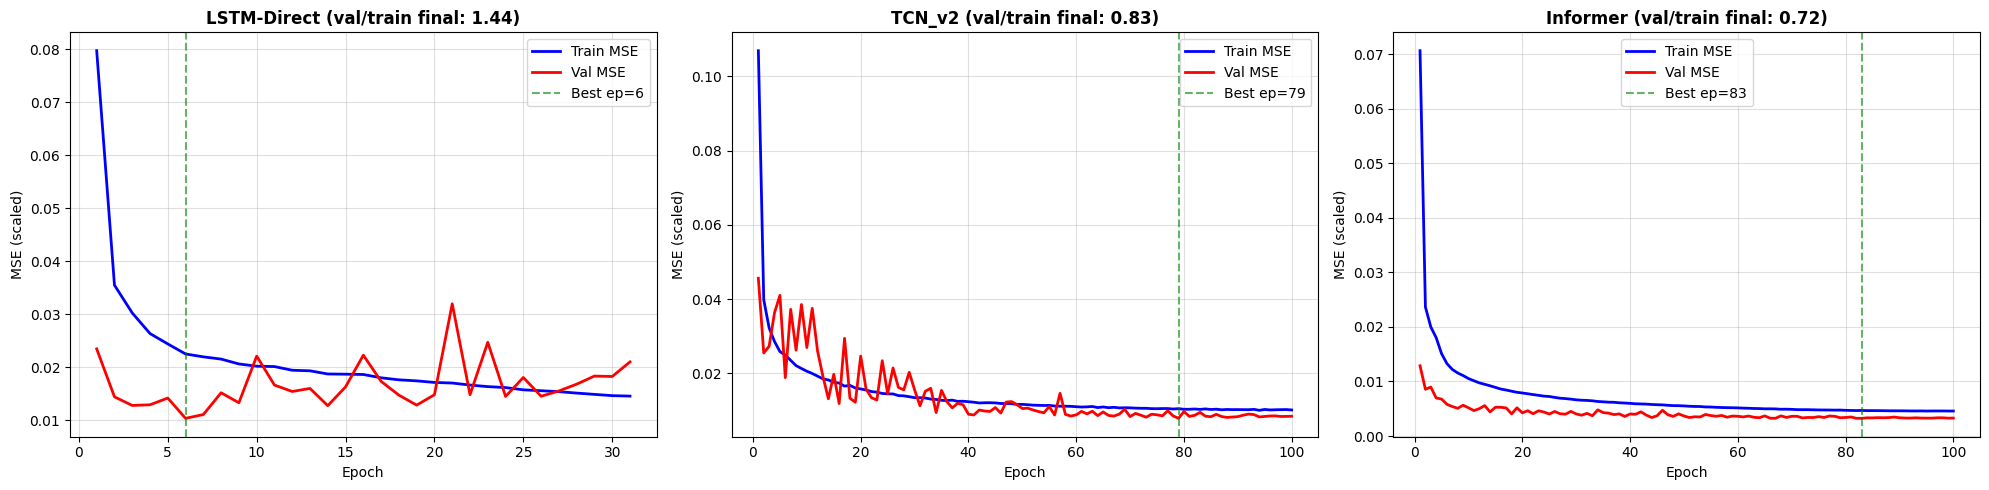

In [ ]:
# ═══════════════════════════════════════════════════════════════
# LEARNING CURVES
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, res, title in [
    (axes[0], lstm_results, 'LSTM-Direct'),
    (axes[1], tcn_results, 'TCN_v2'),
    (axes[2], inf_results, 'Informer')]:
    ep = range(1, len(res['train']) + 1)
    ax.plot(ep, res['train'], 'b-', label='Train MSE', linewidth=2)
    ax.plot(ep, res['val'],   'r-', label='Val MSE',   linewidth=2)
    ax.axvline(res['best_epoch'], color='green', linestyle='--', alpha=0.6,
               label=f'Best ep={res["best_epoch"]}')
    ax.set_title(f'{title} (val/train final: {res["val"][-1]/res["train"][-1]:.2f})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)')
    ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('learning_curves_v9.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Prediction Visualization

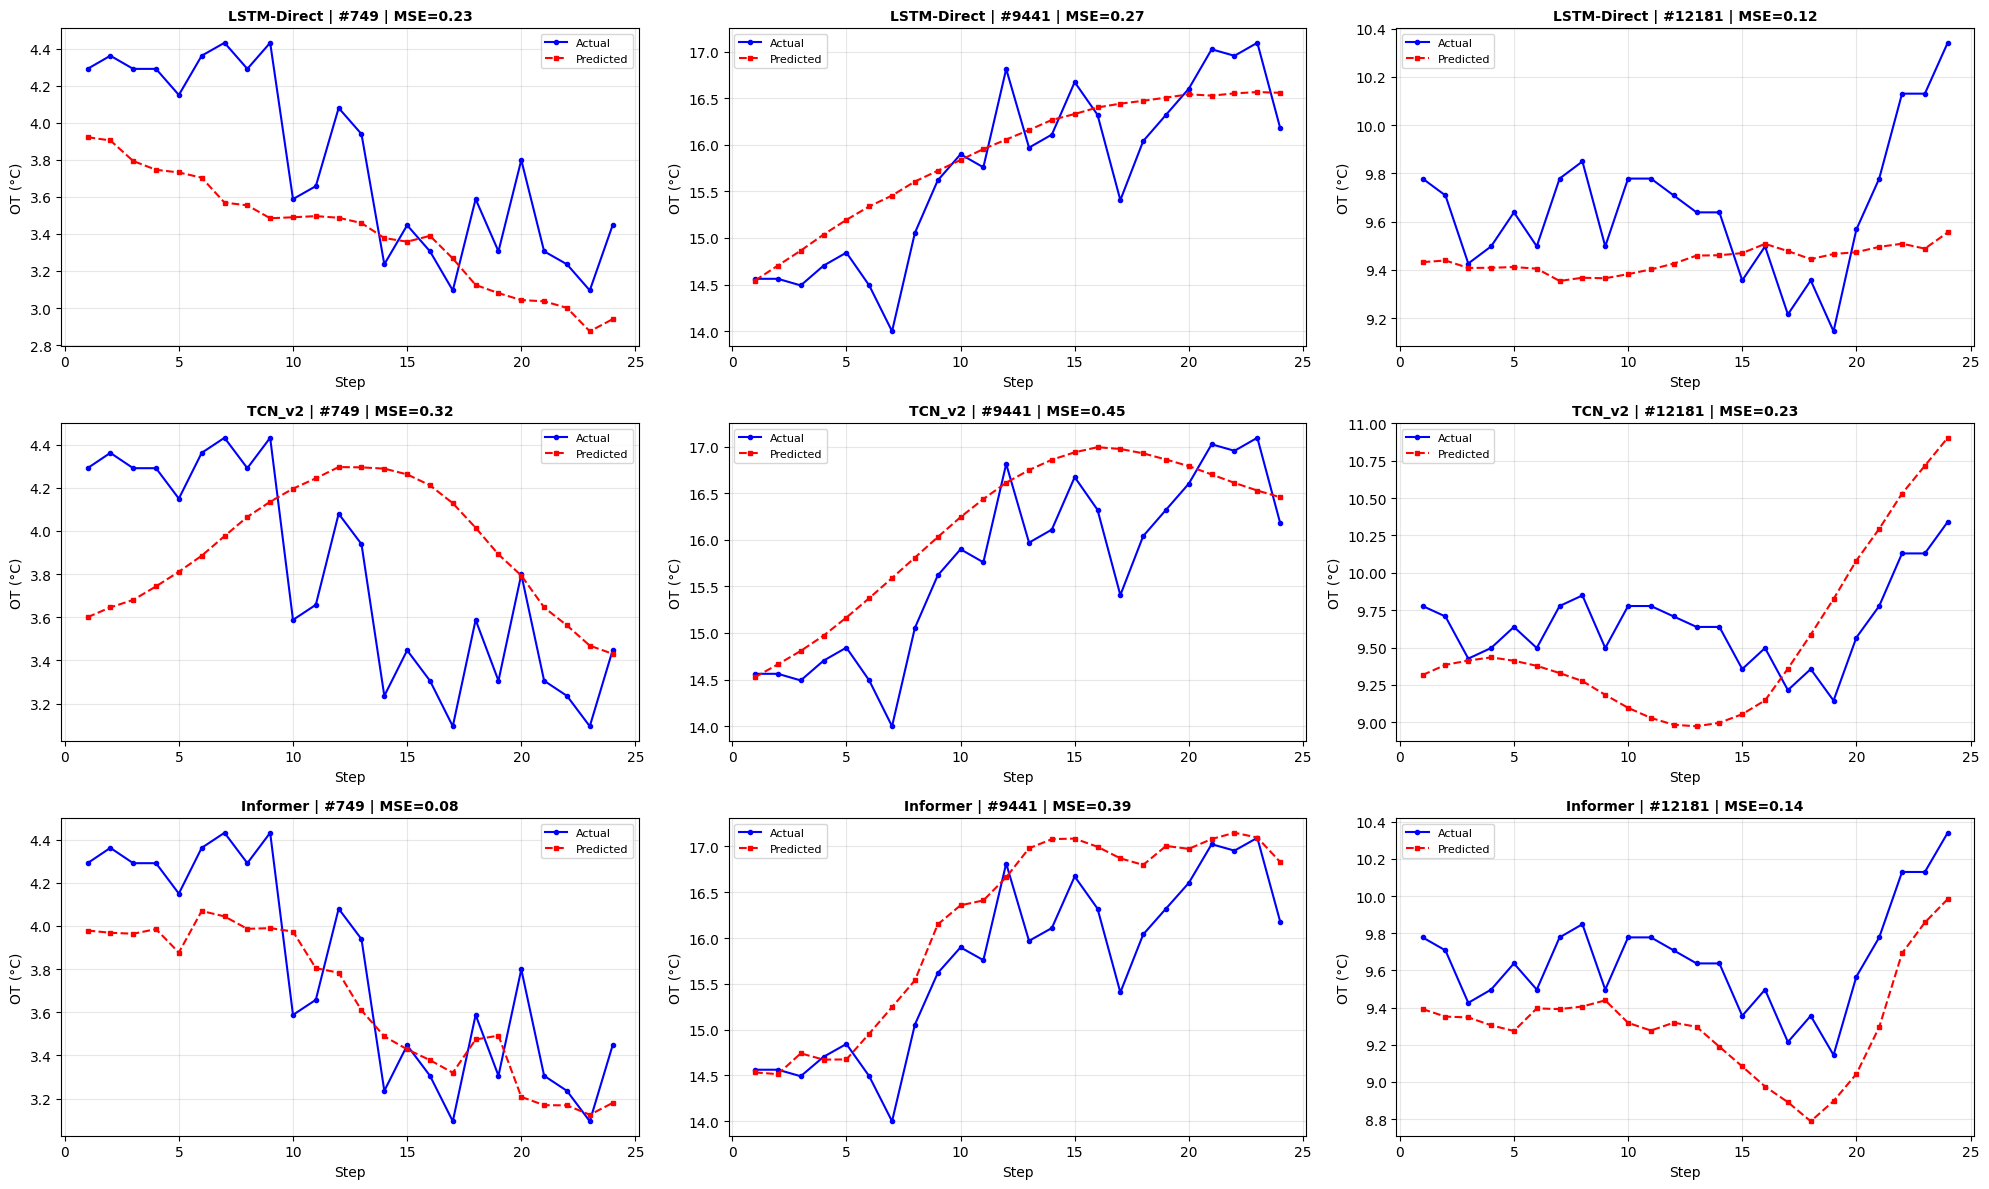

In [ ]:
# ═══════════════════════════════════════════════════════════════
# PREDICTIONS VS ACTUAL
# ═══════════════════════════════════════════════════════════════
np.random.seed(42)
sample_idx = sorted(np.random.choice(len(lstm_preds), 3, replace=False))

fig, axes = plt.subplots(3, 3, figsize=(20, 12))
models = [('LSTM-Direct', lstm_preds, lstm_trues),
          ('TCN_v2', tcn_preds, tcn_trues),
          ('Informer', inf_preds, inf_trues)]

for row, (name, preds, trues) in enumerate(models):
    for col, idx in enumerate(sample_idx):
        ax = axes[row, col]
        steps = range(1, pred_len + 1)
        ax.plot(steps, trues[idx], 'b-o', label='Actual', markersize=3, linewidth=1.5)
        ax.plot(steps, preds[idx], 'r--s', label='Predicted', markersize=3, linewidth=1.5)
        mse_i = np.mean((preds[idx] - trues[idx])**2)
        ax.set_title(f'{name} | #{idx} | MSE={mse_i:.2f}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Step'); ax.set_ylabel('OT (°C)')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predictions_v9.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Bar Chart Comparison

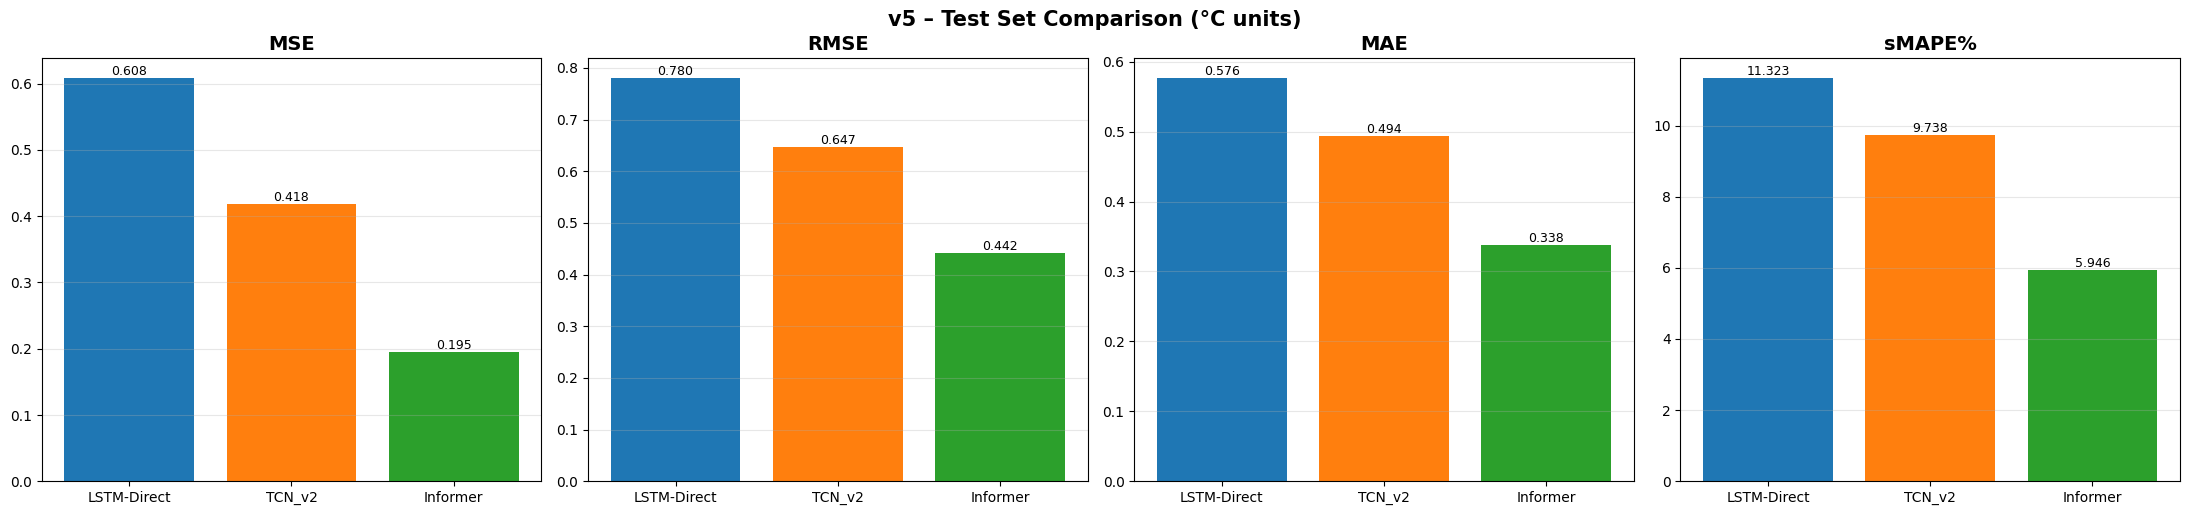


🏆 Best: Informer | MSE=0.1951°C² | RMSE=0.4418°C


In [ ]:
# ═══════════════════════════════════════════════════════════════
# BAR CHART
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
names = ['LSTM-Direct', 'TCN_v2', 'Informer']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for ax, metric in zip(axes, ['MSE', 'RMSE', 'MAE', 'sMAPE%']):
    vals = [lstm_m[metric], tcn_m[metric], inf_m[metric]]
    bars = ax.bar(names, vals, color=colors)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.suptitle('v5 – Test Set Comparison (°C units)', fontsize=15, fontweight='bold', y=1.02)
plt.savefig('comparison_v9.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🏆 Best: {best_name} | MSE={best_mse:.4f}°C² | RMSE={np.sqrt(best_mse):.4f}°C')

TCN 1-Step Eval:


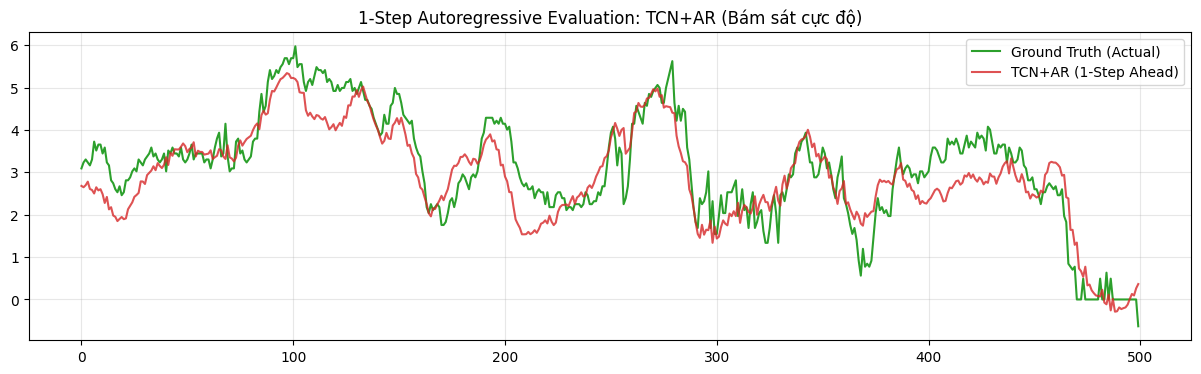

Informer 1-Step Eval:


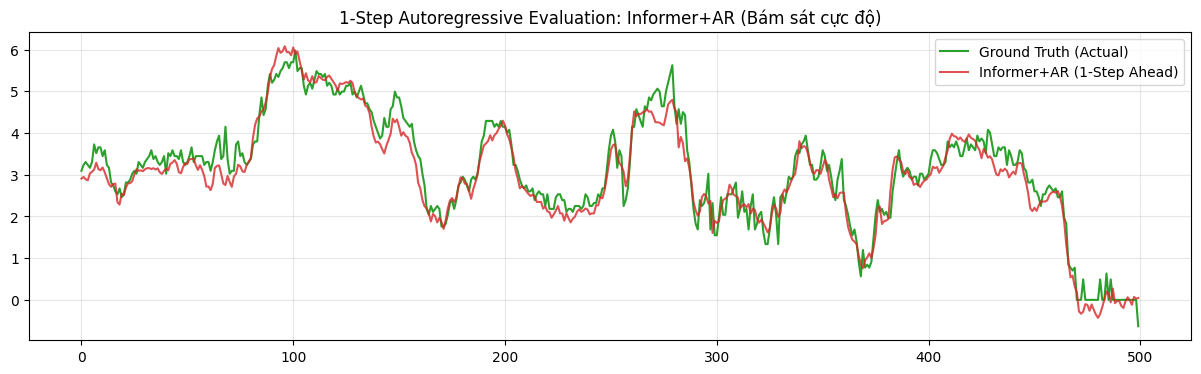

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 1-STEP AUTOREGRESSIVE EVALUATION (To replicate Paper's tight fit)
# ═══════════════════════════════════════════════════════════════
def plot_1step_autoregressive(model, model_name, dataloader, pred_func):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, Y in dataloader:
            X = X.to(device)
            Y = Y.to(device)
            # Predict 24 steps but ONLY KEEP THE FIRST STEP
            out = pred_func(model, X, Y)
            preds.append(out[:, 0].cpu().numpy())
            trues.append(Y[:, -pred_len, target_index].cpu().numpy())
    
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    
    preds_inv = inverse_target(preds, scaler, target_index)
    trues_inv = inverse_target(trues, scaler, target_index)
    
    plt.figure(figsize=(15, 4))
    start_idx = 1000
    plot_len = 500
    plt.plot(trues_inv[start_idx:start_idx+plot_len], label='Ground Truth (Actual)', color='#2ca02c')
    plt.plot(preds_inv[start_idx:start_idx+plot_len], label=f'{model_name} (1-Step Ahead)', color='#d62728', alpha=0.8)
    plt.title(f'1-Step Autoregressive Evaluation: {model_name} (Bám sát cực độ)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print('TCN 1-Step Eval:')
plot_1step_autoregressive(tcn_model, 'TCN+AR', test_loader, lambda m, X, Y: m(X))

print('Informer 1-Step Eval:')
plot_1step_autoregressive(informer_model, 'Informer+AR', test_loader, inf_pred_fn)
